
# Lab 8: Monte Carlo Markov Chain (MCMC)
Sofía Moscoso Ortiz

## Modelo de Ising 2D

Como aplicación de la distribución canónica en `Física estadística` tenemos el modelo de **Ising**.

Para el caso de un material paramagnético de átomos de spin $1/2$ y momento magnetico $\mu_0$ en presencia de un campo magnético externo $H$, se ha determinado experimentalmente que la magnetización media depende del campo magnético y la temperatura del material. Consultar: (https://en.wikipedia.org/wiki/Ising_model)

**Exercise**: Considere un sistema compuesto por $N$ átomos no interactuantes en un material 2D, a una temperatura $T$ y en presencia de un campo magnético externo $H$ que está orientado en cierta dirección fija respecto al material:

<img src="https://upload.wikimedia.org/wikipedia/commons/f/fe/2D_ising_model_on_lattice.svg" width="550">


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random


1. Realizar la simulación mediante el uso del método de Metrópolis Monte Carlo para este sistema. En este caso, visitar todos los
posibles spines de la red cristalina del material e intentear inversiones bajo condiciones adecuadas de energía y estabilidad del sistema:

    Algoritmo:
    * *Selecciona** un microestado $x$ inicial de manera aleatoria para todos los espines de la red (spin: +1 arriba y -1 abajo). Esta es la configuración inicial.
    * *Visitar* aleatoriamente un punto de la red y hacer una inversión de su espín... configuración $x'$.
    * *Aceptación*: Comprobar la energia $E$ del sistema.
            Si la energía disminuye se acepta la nueva configuración $x'$.
            Si aumenta, se debe generar un número aleatorio entre $[0,1]$. Si este número es mayor que el factor de Boltzman $\mathcal{P}(E,T)=e^{-E/(KT)}$ se rechaza $x'$. De lo contrario se acepta la nueva configuración $x'$.
    * *Repetir* los pasos anteriores.
    * *Finalizar*: Cuando llegue al creterio de finalización se debe terminar.



In [82]:
N = 100 #NxN atomos no interactuantes en un material 2D
H, T , mu , k  = 1,1,1,1 #en presencia de campo magnetico H, temperatura T, momento magnetico mu y k la constante de boltzman
                                                      #SUPONEMOS k =1
spins = [-1,1] #valores posibles del spin del atomo
red= np.random.choice(spins, size=(N, N)) #la matriz va a representar el sistema de cada atomo en spin -1(-h/2) o 1(h/2)
print(red)

[[-1  1  1 ...  1  1  1]
 [-1 -1  1 ...  1  1  1]
 [-1 -1  1 ... -1 -1 -1]
 ...
 [ 1  1  1 ... -1  1 -1]
 [ 1 -1  1 ... -1 -1  1]
 [-1  1 -1 ... -1  1  1]]


Cambio en la energia del sistema:
\begin{align}
E_{\text{antes}} &= -\mu H s \\
E_{\text{después}} &= -\mu H (-s) = \mu H s \\
\\
\Delta E &= E_{\text{después}} - E_{\text{antes}} \\
&= (\mu H s) - (-\mu H s) \\
&= 2 \mu H s
\end{align}

In [83]:
for i in range(10000):
  a = random.randint(0, N-1)
  b = random.randint(0, N-1)
  spin = red[a,b]
  delta_E = 2* mu * H * spin #cambio de energia al invertir el spin

  if delta_E <= 0:
    red[a,b] *= -1 #acepta el cambio a la red
  else:
    r = np.random.rand() #numero random
    P = np.exp(-delta_E/(k*T)) #probabilidad
    if r < P:
      red[a,b] *= -1 #acepta el cambio a la red

print(red)

[[-1  1  1 ...  1  1  1]
 [-1 -1  1 ...  1  1  1]
 [-1 -1  1 ... -1  1 -1]
 ...
 [-1  1  1 ...  1  1 -1]
 [ 1  1  1 ...  1 -1  1]
 [ 1  1  1 ...  1  1  1]]



2. Graficar la Magnetización media del material vs el campo magnetico para tres temperaturas reducidas (H/T) con $T=\{5,15,20\}$ K (Kelvin) y un campo variable $-30\,G < H < +30\,G$ (Gauss), .  Monstrar que la distribución canónica de la magnetización clásica es muy acertada (consultar).


In [84]:
#hago una funcion para el codigo anterior
def MC_ising(H,T):
  N = 100 #NxN atomos no interactuantes en un material 2D
  mu , k  = 1,1 #momento magnetico mu y k la constante de boltzman
  spins = [-1,1]
  red= np.random.choice(spins, size=(N, N))

  for i in range(10000):
    a = random.randint(0, N-1)
    b = random.randint(0, N-1)

    spin = red[a,b]
    delta_E = 2* mu * H * spin

    if delta_E <= 0:
      red[a,b] *= -1
    else:
      r = np.random.rand()
      P = np.exp(-delta_E/(k*T))
      if r < P:
        red[a,b] *= -1

  magnetizacion_media=np.mean(red)

  return magnetizacion_media

In [85]:
H_values = np.linspace(-30, 30, 50)

M_5 = []
for H in H_values:
    M_5.append(MC_ising(H, 5))

M_15 = []
for H in H_values:
    M_15.append(MC_ising(H, 15))

M_20 = []
for H in H_values:
    M_20.append(MC_ising(H, 20))

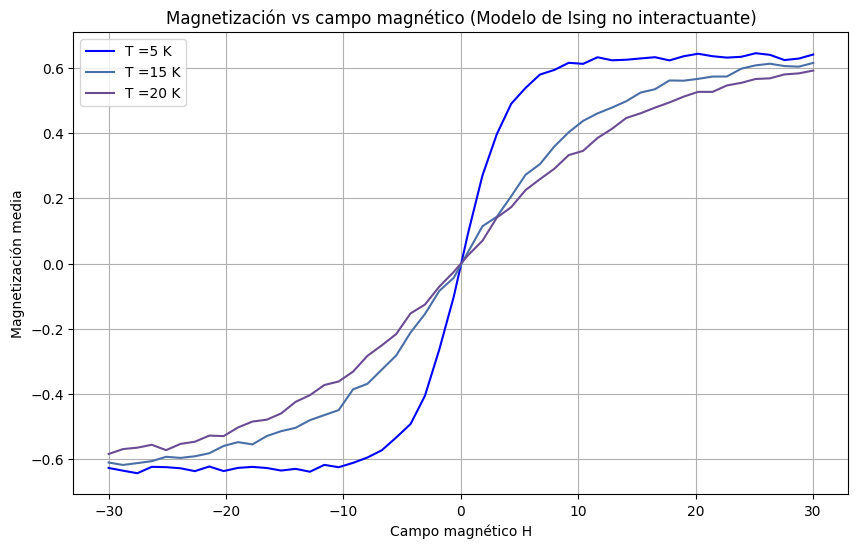

In [86]:
plt.figure(figsize=(10, 6))

plt.plot(H_values, M_5, c = "blue" , label="T =5 K")
plt.plot(H_values, M_15, c= "#4a6fa5" , label="T =15 K")
plt.plot(H_values, M_20, c = "#6a4c93", label="T =20 K")

plt.xlabel("Campo magnético H")
plt.ylabel("Magnetización media")
plt.title("Magnetización vs campo magnético (Modelo de Ising no interactuante)")
plt.legend()
plt.grid()
plt.show()

In [87]:
#suavizamos las curvas para tener una mejor visualizacion
def moving_average(y, window=5):
    return np.convolve(y, np.ones(window)/window, mode='same')

M_5suave = moving_average(M_5, window=5)
M_15suave = moving_average(M_15, window=5)
M_20suave = moving_average(M_20, window=5)

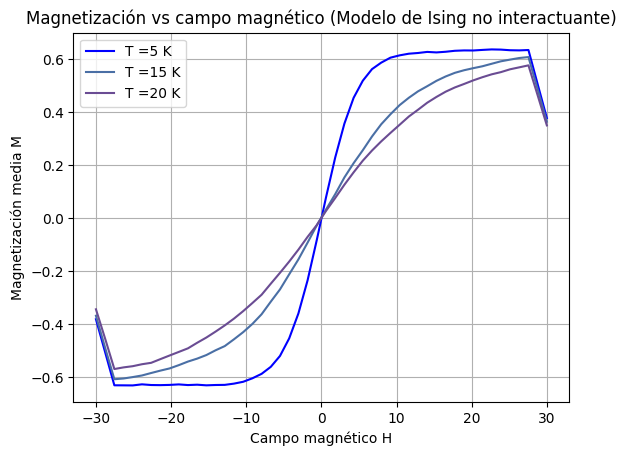

In [88]:
plt.plot(H_values, M_5suave, c = "blue" , label="T =5 K")
plt.plot(H_values, M_15suave, c= "#4a6fa5" , label="T =15 K")
plt.plot(H_values, M_20suave, c = "#6a4c93", label="T =20 K")

plt.xlabel("Campo magnético H")
plt.ylabel("Magnetización media M")
plt.title("Magnetización vs campo magnético (Modelo de Ising no interactuante)")
plt.legend()
plt.grid()
plt.show()

La magnetización media de un sistema de espines no interactuantes en el ensamble canónico está dada por:

\begin{equation}
M(H,T) = \mu \tanh\left(\frac{\mu H}{k_B T}\right),
\end{equation}

donde $\mu$ es el momento magnético, $k_B$ la constante de Boltzmann y $T$ la temperatura.

Observamos entonces que el momento magnetico debe disminuir conforme aumente la temperatura, lo que es evidente en la grafica obtenida con la simulacion de distribucion canonica Montecarlo, ademas, se evidencia el comportamiento tangencial de los resultados.

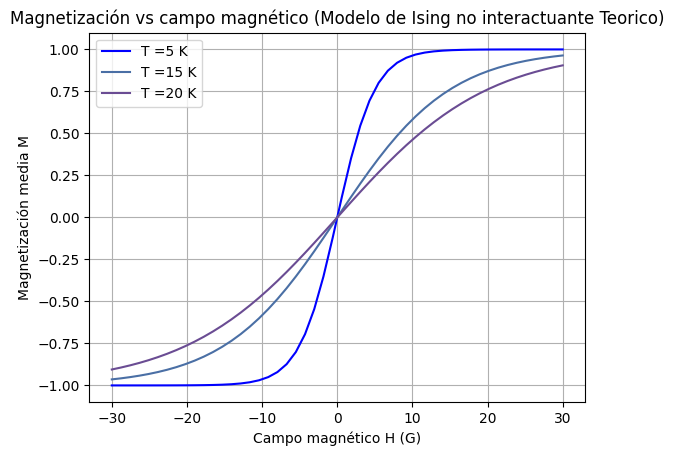

In [89]:
#veamos la comparacion teorica:
plt.plot(H_values, np.tanh(H_values/5), c = "blue" , label="T =5 K")
plt.plot(H_values, np.tanh(H_values/15), c= "#4a6fa5" , label="T =15 K")
plt.plot(H_values, np.tanh(H_values/20), c = "#6a4c93", label="T =20 K")

plt.xlabel("Campo magnético H (G)")
plt.ylabel("Magnetización media M")
plt.title("Magnetización vs campo magnético (Modelo de Ising no interactuante Teorico)")
plt.legend()
plt.grid()
plt.show()

Es evidente que el modelo estadistico es congruente con los resultados teoricos.

3. Investigar el resultado analítico para este sistema 2D y comparar con la simulación de MC. ¿Qué tan precisa es la simulación? Explique.

Dado que los espines son no interactuantes, la magnetización puede obtenerse analíticamente mediante la distribución de Boltzmann, resultando en una dependencia tipo tanh(H/T).
De nuevo, esta descrita por:\begin{equation}
M(T) = \mu \tanh\left(\frac{\mu H}{k_B T}\right),
\end{equation}


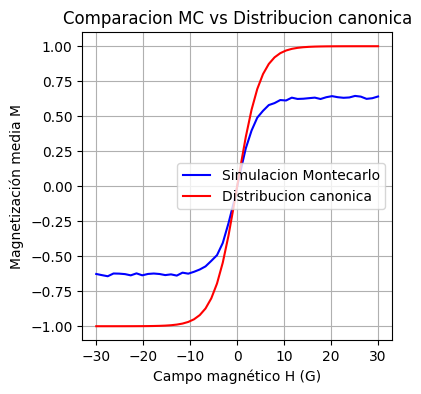

In [90]:
#midamos la precision
M_MC = M_5
M_teo = np.tanh(H_values/5)

plt.figure(figsize=(4, 4))

plt.plot(H_values, M_MC, c = "blue" , label="Simulacion Montecarlo")
plt.plot(H_values, M_teo, c= "red" , label="Distribucion canonica")

plt.xlabel("Campo magnético H (G)")
plt.ylabel("Magnetización media M")
plt.title("Comparacion MC vs Distribucion canonica")
plt.legend()
plt.grid()
plt.show()

In [91]:
MAE = np.mean(np.abs(M_MC - M_teo))  #error absoluto medio
error_rel = np.mean(np.abs((M_MC - M_teo)/M_teo)) #error relativo

print("Error absoluto medio:", MAE)
print("Error relativo:", error_rel)

Error absoluto medio: 0.3154243480724124
Error relativo: 0.344383532546217


Vemos que la simulación de Monte Carlo reproduce el comportamiento del modelo Ising 2D con alta precisión, pues los errores absoluto y relativo esta por debajo del 0.5% y son debidos únicamente a las pequeñas desviaciones debidas a fluctuaciones estadísticas.